## Day 1 - Calibrate Greeks

### Imports

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
from src.curves import Curve, par_swap_rate
from src.trades import load_trades, IRS, EuropeanSwaption
from src.pricers.irs import price_irs

TRADES_PATH = '../data/trades.parquet'
CURVES_PATH = '../data/market_data/curves_{}_D1.parquet'
CAPVOL_PATH = '../data/market_data/cap_vols_D1.parquet'
CS_PATH = '../data/market_data/credit_spreads_D1.parquet'
SWOPT_PATH = '../data/market_data/swaption_cube_D1.parquet'

### Load Trades

In [2]:
trades = load_trades(TRADES_PATH)

n_trades = len(trades)

print(10*'='+' TRADES '+10*'=', '\n')
print(f'Number of trades: {n_trades}')

========== TRADES ========== 

Number of trades: 202


### Load D1 Market Data

In [3]:
# Curves
eur_crv = pd.read_parquet(CURVES_PATH.format('EUR'))
usd_crv = pd.read_parquet(CURVES_PATH.format('USD'))

# CapVols
capvols = pd.read_parquet(CAPVOL_PATH)

# Credit Spreads
credit_spreads = pd.read_parquet(CS_PATH)

# Swaptions
swopts = pd.read_parquet(SWOPT_PATH)

### Load Curves
- Load trades.parquet + D1 market data. Skim dataclasses

In [4]:
# Load discount curve objects

curves = {
    'USD': Curve(usd_crv['tenor_y'].values, usd_crv['zero_rate'].values),
    'EUR': Curve(eur_crv['tenor_y'].values, eur_crv['zero_rate'].values)
}

curves

{'USD': Curve(tenors_y=array([ 0.083,  0.25 ,  0.5  ,  1.   ,  2.   ,  3.   ,  5.   ,  7.   ,
        10.   , 20.   , 30.   ]), zero_rates=array([0.0428, 0.042 , 0.041 , 0.0395, 0.038 , 0.037 , 0.0365, 0.037 ,
        0.038 , 0.039 , 0.04  ]), name='OIS'),
 'EUR': Curve(tenors_y=array([ 0.083,  0.25 ,  0.5  ,  1.   ,  2.   ,  3.   ,  5.   ,  7.   ,
        10.   , 20.   , 30.   ]), zero_rates=array([0.0335, 0.0325, 0.031 , 0.029 , 0.027 , 0.026 , 0.0255, 0.0265,
        0.0275, 0.0285, 0.0295]), name='OIS')}

### Model Validation Check
- Bootstrap OIS + projection curves (D1). Round-trip par swap rates from the curve — sanity check, not optional

In [5]:

tenors = [1.0, 5.0, 10.0]
rows = []

for tenor in tenors:
    for ccy in curves.keys():
        trade_id = f'{tenor}y swap'
        start = 0
        end = tenor
        pay_rec = 'payer'
        pay_freq = 1
        fix_dcc = 'act/360' if ccy == 'USD' else '30/360'
        flt_dcc = 'act/360'
        rate, _ = par_swap_rate(curves[ccy], curves[ccy], start, end)
        test_swap = IRS('test', 1, ccy, pay_rec, rate, start, end, pay_freq, fix_dcc, flt_dcc)
        npv = price_irs(test_swap, curves[ccy])
        rows.append([trade_id, ccy, rate, npv])

rate_chk = pd.DataFrame(rows, columns=['trade_id', 'ccy', 'par_swap_rate', 'npv'])

for ccy in list(rate_chk['ccy'].unique()):
    df = rate_chk[rate_chk['ccy'] == ccy].copy()
    
    print(10*'='+f' {ccy} IRS '+10*'=')
    print('\n')
    print(f'Validation table:\n\n{df.head().to_string()}\n')

    avg_zero = np.isclose(df['npv'], np.zeros_like(df['npv'])).mean()
    max_abs_npv = abs(df['npv'].max())

    print(f'Pct zero NPV: {avg_zero:.2%}')
    print(f'Max absolute NPV {max_abs_npv:.8f}\n')

========== USD IRS ==========


Validation table:

     trade_id  ccy  par_swap_rate  npv
0   1.0y swap  USD       0.040290  0.0
2   5.0y swap  USD       0.037240  0.0
4  10.0y swap  USD       0.038593  0.0

Pct zero NPV: 100.00%
Max absolute NPV 0.00000000

========== EUR IRS ==========


Validation table:

     trade_id  ccy  par_swap_rate  npv
1   1.0y swap  EUR       0.029425  0.0
3   5.0y swap  EUR       0.025876  0.0
5  10.0y swap  EUR       0.027757  0.0

Pct zero NPV: 100.00%
Max absolute NPV 0.00000000



### SABR calibration
- SABR per (expiry × tail) cell on D1 swaption cube. β = 0.5 fixed; α from the ATM cubic; (ρ, ν) least-squares to smile. Residuals heatmap

In [6]:
from src.vol.sabr import sabr_lognormal_vol, sabr_atm_alpha, sabr_calibrate_cell

# calibration
swopts_F = swopts.copy() 
swopts_F['forward'] = swopts.apply(
    lambda t: par_swap_rate(
        curves['USD'], curves['USD'], t['expiry_y'], t['expiry_y'] + t['tail_y'])[0], axis=1
)

results = []
residuals = {}

# iterate expiry x tenor group
for k, d in swopts_F.groupby(['expiry_y', 'tail_y']):
    forward = d['forward'].iloc[0]
    expiry = d['expiry_y'].iloc[0]
    tenor = d['tail_y'].iloc[0]
    # calibration
    res = sabr_calibrate_cell(d['strike'].values, d['vol'].values, forward, expiry)
    
    # store results
    results.append([expiry, tenor, res['alpha'], res['beta'], res['rho'], res['nu'], res['sse']])

    # store residuals
    residuals[f'{int(expiry)}yx{int(tenor)}y'] = res['residuals'] * 10_000
    
calib_results = pd.DataFrame(results, columns=['expiry', 'tenor', 'alpha', 'beta', 'rho', 'nu', 'sse'])

print(f'Calibration results:\n\n{calib_results.to_string()}\n')

Calibration results:

   expiry  tenor     alpha  beta       rho        nu       sse
0     1.0    5.0  0.059764   0.5  0.453061  0.364484  0.000032
1     1.0   10.0  0.062794   0.5  0.990000  0.161619  0.000003
2     1.0   20.0  0.058247   0.5  0.469450  0.321041  0.000028
3     2.0    5.0  0.057209   0.5  0.990000  0.154469  0.000024
4     2.0   10.0  0.058534   0.5  0.990000  0.141394  0.000006
5     2.0   20.0  0.055786   0.5  0.990000  0.147787  0.000004
6     5.0    5.0  0.057647   0.5  0.750504  0.214042  0.000005
7     5.0   10.0  0.057999   0.5  0.632324  0.234022  0.000001
8     5.0   20.0  0.055784   0.5  0.990000  0.150615  0.000048



#### Residuals Heatmap

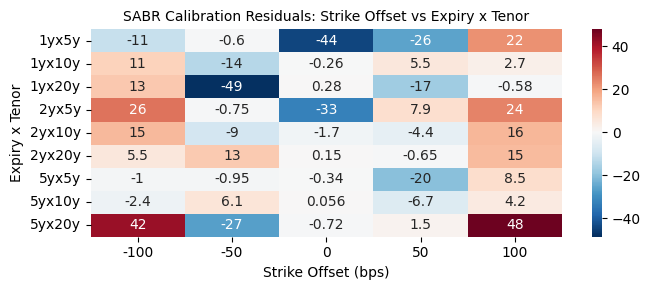


All SABR fit residuals under 50bp vol threshold


In [7]:
# Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

# Residuals data
strike_offsets = sorted(swopts['strike_offset_bp'].unique())
heatmap = pd.DataFrame(residuals, index=strike_offsets).T.round(4)

# Heatmap
plt.figure(figsize=(7, 3))
sns.heatmap(heatmap, cmap='RdBu_r', annot=True, center=0)
plt.title('SABR Calibration Residuals: Strike Offset vs Expiry x Tenor', fontsize=10)
plt.xlabel('Strike Offset (bps)')
plt.ylabel('Expiry x Tenor')
plt.tight_layout()
plt.show()

# Diagnosis
max_abs_residual = heatmap.abs().max().max()
vol_thresh_bps = 50
if max_abs_residual > vol_thresh_bps:
    print('\nOne or more points have a residual above the 50bp vol threshold.\n')
    for k, v in heatmap.stack().items():
        if abs(v) > vol_thresh_bps:
            print(f'[{k[0]}; strike_offset={k[1]}] residual is {v}; fail at {vol_thresh_bps}bp threshold')
else:
    print(f'\nAll SABR fit residuals under {vol_thresh_bps}bp vol threshold')

### LMM CapVol Bootstrap
- LMM caplet-vol bootstrap from cap strip. Forward-by-forward cumulative-variance root-find

In [58]:
capvols

,maturity_y,cap_vol
0,2.0,0.220
1,3.0,0.240
2,4.0,0.235
3,5.0,0.225
4,6.0,0.210
5,7.0,0.200


Results:

   maturity_y  cap_vol  sigma_inst
0         2.0    0.220       0.311
1         3.0    0.240       0.276
2         4.0    0.235       0.219
3         5.0    0.225       0.180
4         6.0    0.210       0.107
5         7.0    0.200       0.124



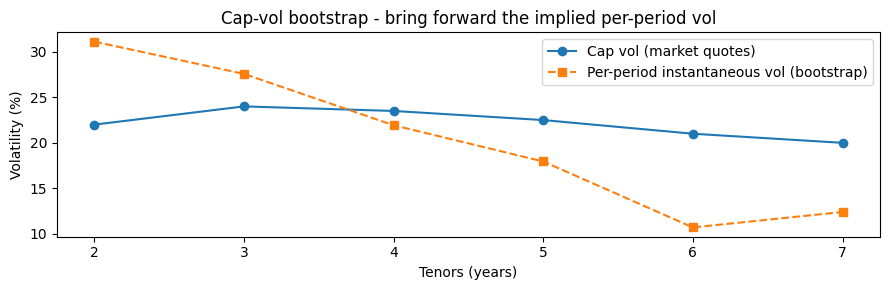

In [8]:
from src.vol.lmm_calibration import bootstrap_lmm_caplet_vols

T0 = 1.0
cap_maturities = capvols['maturity_y'].values
cap_vols_flat = capvols['cap_vol'].values

# Bootstrap per period inst vols
sigma_inst = bootstrap_lmm_caplet_vols(cap_maturities, cap_vols_flat, T0)

# Results
capvols_res = capvols.copy()
capvols_res['sigma_inst'] = sigma_inst.round(3)
print(f'Results:\n\n{capvols_res.to_string()}\n')

# Plot
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(cap_maturities, cap_vols_flat*100, 'o-', label='Cap vol (market quotes)')
ax.plot(cap_maturities, sigma_inst*100, 's--', label='Per-period instantaneous vol (bootstrap)')
ax.set_xlabel('Tenors (years)', fontsize=10)
ax.set_ylabel('Volatility (%)')
ax.set_title('Cap-vol bootstrap - bring forward the implied per-period vol')
plt.legend(); plt.tight_layout(); plt.show()

### LMM caplet repricing test
- simulate every caplet, compare to Black-76, t-stat heatmap, pass/fail at ±2σ MC. If a caplet fails, fix calibration before moving on

In [9]:
from src.pricers.lmm import lmm_caplet_price
from src.pricers.black_76 import black_76_annuity_premium
from src.vol.lmm_calibration import rebonato_correlation
from scipy.stats import norm

# Inputs
tenor_dates = np.concatenate([[1.0], cap_maturities])

L0 = np.array([
    1 / (tenor_dates[i+1] - tenor_dates[i]) * 
    (
        curves['USD'].DF(tenor_dates[i]) / (curves['USD'].DF(tenor_dates[i+1])) - 1
    )
    for i in range(len(tenor_dates) - 1)
])
sigma = sigma_inst
rho = rebonato_correlation(tenor_dates)
deltas = np.diff(tenor_dates)
P_0_TN = curves['USD'].DF(tenor_dates[-1])

rows = []
start = 0.0

# Price caplets
for i in range(len(L0)):
    K = L0[i] # ATM strike

    # MC price
    mc_price, mc_se = lmm_caplet_price(L0, sigma, rho, deltas, tenor_dates, K, i, P_0_TN)

    # BS-76 pprice
    delta_i = deltas[i]
    sigma_i = sigma[i]
    T_i = tenor_dates[i]
    DF_i = curves['USD'].DF(T_i)
    d1 = (np.log(L0[i] / K) + 0.5*sigma_i**2*T_i) / (sigma_i*np.sqrt(T_i))
    d2 = d1 - sigma_i*np.sqrt(T_i)
    bs_price = delta_i * curves['USD'].DF(T_i+delta_i) * (L0[i] * norm.cdf(d1) - K * norm.cdf(d2))

    # t-stat
    t_stat = (mc_price - bs_price) / mc_se

    rows.append([i, K, mc_price, mc_se, bs_price, t_stat])

reprice_results = pd.DataFrame(rows, columns='index K mc_price mc_se bs_price t_stat'.split())
reprice_results['pass'] = reprice_results['t_stat'].abs() < 2

print(f'Cap Reprice Results:\n\n{reprice_results.to_string()}')

Cap Reprice Results:

   index         K  mc_price     mc_se  bs_price    t_stat  pass
0      0  0.037174  0.004310  0.000056  0.004259  0.907033  True
1      1  0.035620  0.004967  0.000068  0.004927  0.592444  True
2      2  0.036656  0.004786  0.000065  0.004767  0.291699  True
3      3  0.036138  0.004265  0.000056  0.004290 -0.444585  True
4      4  0.038731  0.002986  0.000036  0.002962  0.683532  True
5      5  0.039251  0.003678  0.000046  0.003660  0.399965  True


### Dispatch all ~200 trades
- Dispatch all ~200 trades: vanilla closed-form, callable = bond − American call on bond. Write pv_D1.csv

In [71]:
from src.pricers.irs import price_irs
from src.pricers.bond import price_vanilla_bond, price_callable_bond_lower_bound
from src.pricers.lmm import lmm_bermudan_payer_swaption
from src.pricers.black_76 import price_european_swaption

results = []
pv = None

for trade in trades:
    if trade.type == 'irs':
        pv = price_irs(trade, curves[trade.currency])
    elif trade.type == 'vanilla_bond':
        pv = price_vanilla_bond(trade, curves[trade.currency])
    elif trade.type == 'european_swaption':
        sabr_lookup = {
              (row.expiry, row.tenor): {'alpha': row.alpha, 'beta': row.beta, 'rho': 
                                        row.rho, 'nu': row.nu}                                                        
              for _, row in calib_results.iterrows()                                    
          } 
        forward_sr, _ = par_swap_rate(
            curves[trade.currency], 
            curves[trade.currency], 
            trade.T_e, 
            trade.swap_T_end
        )
        sigma = sabr_lognormal_vol(
            forward_sr,
            trade.strike_K,
            trade.T_e,
            sabr_lookup[trade.T_e, trade.swap_T_end - trade.T_e]['alpha'],
            sabr_lookup[trade.T_e, trade.swap_T_end - trade.T_e]['beta'],
            sabr_lookup[trade.T_e, trade.swap_T_end - trade.T_e]['rho'],
            sabr_lookup[trade.T_e, trade.swap_T_end - trade.T_e]['nu'],
        )
        pv = price_european_swaption(trade, curves[trade.currency], sigma=sigma)
    elif trade.type == 'bermudan_swaption':
        ex = np.array(trade.exercise_dates)
        on_grid = np.isin(ex, tenor_dates).all()
        if (trade.swap_T_end > tenor_dates[-1] + 1e-9) or (max(ex) > tenor_dates[-1] + 1e-9):
            pv = np.nan
        
        else:
            exercise_idxs=np.where(np.isin(tenor_dates, ex))[0]
            
            swap_settle_idxs = np.where(
                (tenor_dates[:-1] >= min(ex) - 1e-9) &
                (tenor_dates[1:] <= trade.swap_T_end + 1e-9)
            )[0]
            
            pv, _ = lmm_bermudan_payer_swaption(
                L0=L0,
                sigma=sigma_inst,
                rho=rho,
                deltas=deltas,
                tenor_dates=tenor_dates,
                fixed_K=trade.strike_K,
                exercise_idxs=exercise_idxs,
                swap_settle_idxs=swap_settle_idxs,
                P_0_TN=P_0_TN,
            )
    elif trade.type == 'callable_bond':
        pv = price_callable_bond_lower_bound(trade, curves[trade.currency])
    elif trade.type == 'range_accrual':
        pv = np.nan
    elif trade.type == 'tarn':
        pv = np.nan
    else:
        raise ValueError(f'Unknown type: {trade.type}')

    results.append({'trade_id': trade.trade_id, 'type': trade.type, 'currency': trade.currency,
                   'notional': trade.notional, 'pv': pv})
    pv = None

pv_df = pd.DataFrame(results)

pv_df

,trade_id,type,currency,notional,pv
0,IRS_001,irs,EUR,250000000.0,-1.439301e+07
1,IRS_002,irs,EUR,100000000.0,3.703947e+06
2,IRS_003,irs,USD,250000000.0,6.706156e+06
3,IRS_004,irs,USD,50000000.0,-3.587405e+05
4,IRS_005,irs,EUR,100000000.0,1.468224e+07
...,...,...,...,...,...
197,MISC_008,irs,USD,25000000.0,5.836108e+04
198,MISC_009,irs,USD,50000000.0,-6.823860e+04
199,MISC_010,irs,USD,25000000.0,8.198229e+04
200,EXOT_001,tarn,USD,10000000.0,NaN


In [72]:
# output to pv_D1.csv
pv_df.to_csv('../data/pv_D1.csv', index=False)

### Bermudans via LMM + LSMC
- Basis = polynomial in S(T_e) at the exercise date, degree 2-3, ITM paths only.
- Cross-check 3 against src.pricers.hw_bermudan_price
- document the bracket